<a href="https://colab.research.google.com/github/mustafaarif2k03-tech/Supply-Chain-Analytics-Portfolio-IBA/blob/main/MGT353_Forecasting_M1_MustafaArif_ColgatePalmolive_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ACF lags 1,4,13,26,52: [-0.11, 0.06, 0.02, -0.06, 0.01]


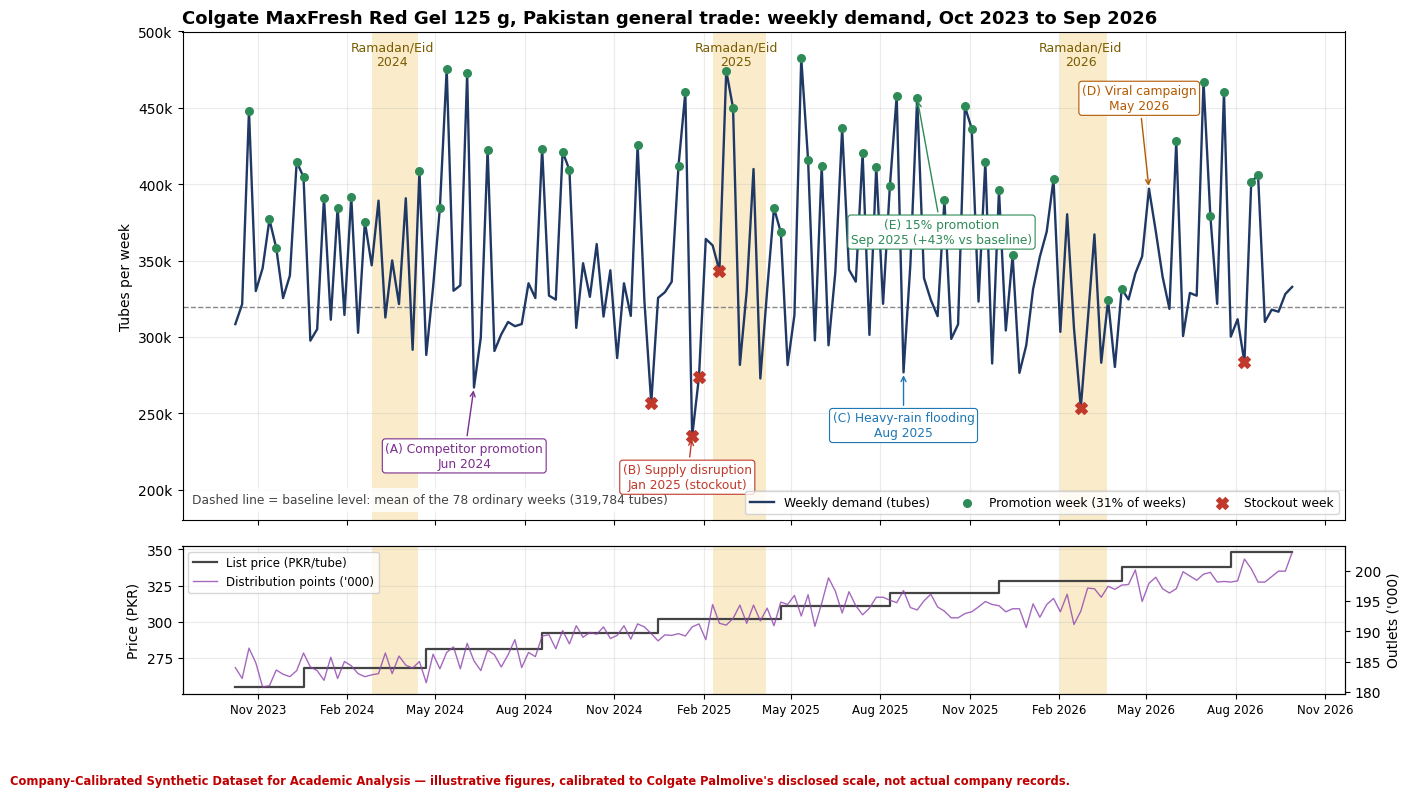

In [2]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

BANNER = "Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Colgate Palmolive's disclosed scale, not actual company records."
df = pd.read_csv("colgate_maxfresh_weekly_synthetic.csv", keep_default_na=False, parse_dates=["Week_Start_Date"])
d, a = df.Week_Start_Date, df.Actual_Demand

clean = (df.Event_Flag == 0) & (df.Promo_Flag == 0) & (df.Stockout_Flag == 0) & (df.Exceptional_Event == "")
x = a.values - a.values.mean()
print("ACF lags 1,4,13,26,52:", [round(float((x[:-k] * x[k:]).sum() / (x * x).sum()), 2) for k in (1, 4, 13, 26, 52)])

plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 10})
fig, (ax, ax2) = plt.subplots(2, 1, figsize=(15, 8.6), sharex=True, gridspec_kw={"height_ratios": [3.3, 1], "hspace": .08})

# Ramadan/Eid windows
ev = (df.Event_Flag == 1).values
i = 0
while i < len(df):
    if ev[i]:
        j = i
        while j + 1 < len(df) and ev[j + 1]:
            j += 1
        for axx in (ax, ax2):
            axx.axvspan(d[i], d[j] + pd.Timedelta(days=6), color="#F4D58D", alpha=.45, lw=0)
        ax.text(d[i] + (d[j] - d[i]) / 2, 494000, f"Ramadan/Eid\n{d[i].year}", ha="center", va="top", fontsize=9, color="#7A5C00")
        i = j + 1
    else:
        i += 1

ax.axhline(a[clean].mean(), color="#888", ls="--", lw=1)
ax.text(0.008, 0.035, f"Dashed line = baseline level: mean of the {clean.sum()} ordinary weeks ({a[clean].mean():,.0f} tubes)", transform=ax.transAxes, fontsize=8.8, color="#444", bbox=dict(fc="white", ec="none", alpha=.85))
ax.plot(d, a, color="#1F3864", lw=1.7, label="Weekly demand (tubes)")

pm = df.Promo_Flag == 1
ax.scatter(d[pm], a[pm], s=30, color="#2E8B57", zorder=3, label="Promotion week (31% of weeks)")

so = df.Stockout_Flag == 1
ax.scatter(d[so], a[so], s=70, marker="X", color="#C0392B", zorder=4, label="Stockout week")

def note(date, text, dy, dx=0, color="#222"):
    r = df[df.Week_Start_Date == pd.Timestamp(date)].iloc[0]
    ax.annotate(
        text,
        xy=(r.Week_Start_Date, r.Actual_Demand),
        xytext=(r.Week_Start_Date + pd.Timedelta(days=dx), r.Actual_Demand + dy),
        fontsize=8.8, ha="center", color=color,
        arrowprops=dict(arrowstyle="->", color=color, lw=1),
        bbox=dict(boxstyle="round,pad=.25", fc="white", ec=color, lw=.8)
    )

note("2024-06-10", "(A) Competitor promotion\nJun 2024", -52000, -10, "#7B2D8E")
note("2025-01-20", "(B) Supply disruption\nJan 2025 (stockout)", -34000, -5, "#C0392B")
note("2025-08-25", "(C) Heavy-rain flooding\nAug 2025", -42000, 0, "#1F77B4")
note("2026-05-04", "(D) Viral campaign\nMay 2026", 52000, -10, "#B35900")
note("2025-09-08", "(E) 15% promotion\nSep 2025 (+43% vs baseline)", -95000, 25, "#2E8B57")

ax.set_ylim(180000, 500000)
ax.set_ylabel("Tubes per week")
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v/1000:,.0f}k"))
ax.set_title("Colgate MaxFresh Red Gel 125 g, Pakistan general trade: weekly demand, Oct 2023 to Sep 2026", loc="left", fontsize=13, fontweight="bold")
ax.legend(loc="lower right", ncol=3, fontsize=8.8, frameon=True)
ax.grid(alpha=.25)

ax2.step(d, df.Price, where="post", color="#444", lw=1.6, label="List price (PKR/tube)")
ax2.set_ylabel("Price (PKR)")
ax2.grid(alpha=.25)

ax3 = ax2.twinx()
ax3.plot(d, df.Distribution_Points, color="#8E44AD", lw=1, alpha=.8, label="Distribution points ('000)")
ax3.set_ylabel("Outlets ('000)")

h1, l1 = ax2.get_legend_handles_labels()
h2, l2 = ax3.get_legend_handles_labels()
ax2.legend(h1 + h2, l1 + l2, loc="upper left", fontsize=8.5)
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.setp(ax2.get_xticklabels(), rotation=0, fontsize=8.5)

fig.text(0.01, 0.005, BANNER, fontsize=8.3, color="#C00000", fontweight="bold")
plt.show()

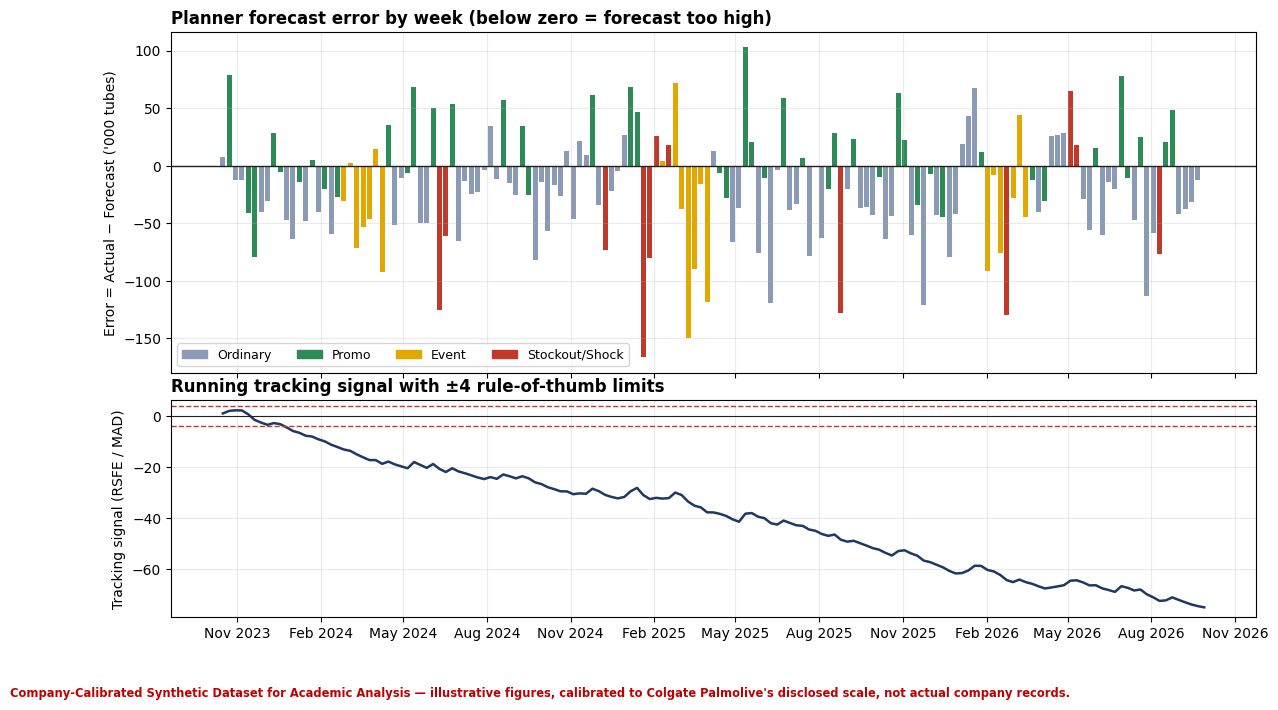

Tracking Signal First Breach: 2023-12-25
Overall Mean Absolute Error (MAE): 42,632 tubes


In [3]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

BANNER = "Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Colgate Palmolive's disclosed scale, not actual company records."
df = pd.read_csv("colgate_maxfresh_weekly_synthetic.csv", keep_default_na=False, parse_dates=["Week_Start_Date"])
df["Err"] = df.Actual_Demand - df.Historical_Forecast
df["Seg"] = np.where((df.Stockout_Flag==1)|(df.Exceptional_Event!=""), "Stockout/Shock", np.where(df.Event_Flag==1, "Event", np.where(df.Promo_Flag==1, "Promo", "Ordinary")))

full = df.iloc[1:].reset_index(drop=True)
N = len(full); R0, R1 = 4, 4+N-1; H0 = R1-25
a, e = full.Actual_Demand.values, full.Err.values
mean, mae = a.mean(), abs(e).mean()

rs = np.cumsum(e)
ts = rs / np.cumsum(abs(e)) * np.arange(1, N+1)
first_breach = full.Week_Start_Date[abs(ts)>4].iloc[0]

# Colab Chart Rendering
col = {"Ordinary": "#8C9BB5", "Promo": "#2E8B57", "Event": "#E0A800", "Stockout/Shock": "#C0392B"}
d = pd.to_datetime(full.Week_Start_Date)
fig, (x1, x2) = plt.subplots(2, 1, figsize=(14, 7.6), sharex=True, gridspec_kw={"height_ratios": [2.2, 1.4], "hspace": .1})

x1.bar(d, full.Err / 1000, width=5.5, color=[col[s] for s in full.Seg])
x1.axhline(0, color="#222", lw=1)
x1.set_ylabel("Error = Actual − Forecast ('000 tubes)")
x1.set_title("Planner forecast error by week (below zero = forecast too high)", loc="left", fontweight="bold")

from matplotlib.patches import Patch
x1.legend(handles=[Patch(color=v, label=k) for k, v in col.items()], ncol=4, loc="lower left", fontsize=9)
x1.grid(alpha=.25)

x2.plot(d, ts, color="#1F3864", lw=1.8)
x2.axhline(4, color="#C0392B", ls="--", lw=1)
x2.axhline(-4, color="#C0392B", ls="--", lw=1)
x2.axhline(0, color="#222", lw=.8)
x2.set_ylabel("Tracking signal (RSFE / MAD)")
x2.set_title("Running tracking signal with ±4 rule-of-thumb limits", loc="left", fontweight="bold")
x2.grid(alpha=.25)
x2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
x2.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

fig.text(0.01, 0.005, BANNER, fontsize=8.3, color="#C00000", fontweight="bold")
plt.show()

print(f"Tracking Signal First Breach: {first_breach.date()}")
print(f"Overall Mean Absolute Error (MAE): {mae:,.0f} tubes")

,MAD,MAPE %,RMSE,WAPE %,Bias,RSFE,Tracking Signal,Managerial comment
Naive,60121.8,18.4,63540.3,17.6,-38498.8,-461985.0,-7.7,
Seasonal Naive (52 wk),75096.0,21.8,92274.8,22.0,-23233.3,-278800.0,-3.7,
Moving Average (4 wk),58262.9,17.7,61359.1,17.1,-34781.0,-417372.0,-7.2,
SES alpha=0.3,59105.6,18.0,62330.0,17.3,-36466.4,-437597.3,-7.4,
SES alpha=0.6,66639.1,20.7,72186.7,19.6,-51533.4,-618401.2,-9.3,
Event-adjusted Holt (Event_Flag),46272.3,13.4,51696.9,13.6,-10786.3,-129435.3,-2.8,
Event+Promo-adjusted Holt (planned promos),16192.5,4.8,20609.9,4.8,-7249.3,-86992.1,-5.4,
Holt-Winters additive (52 wk),53216.4,15.0,69717.3,15.6,-8497.7,-101973.0,-1.9,


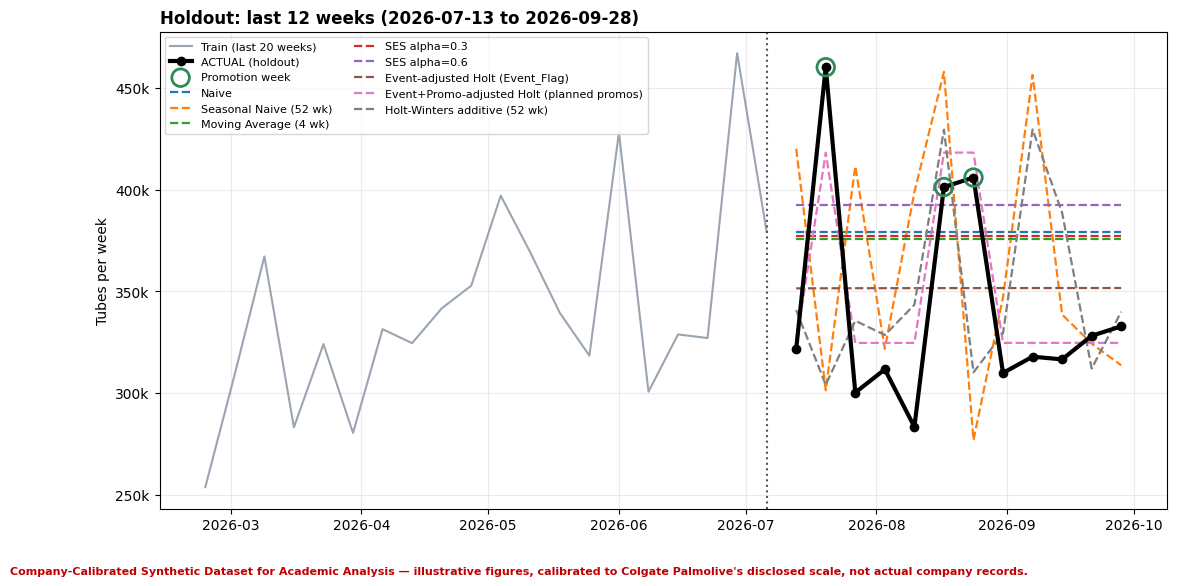

In [4]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BANNER = "Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Colgate Palmolive's disclosed scale, not actual company records."
N_TEST = 12
M = 52
ALPHAS = (0.3, 0.6)

df = pd.read_csv("colgate_maxfresh_weekly_synthetic.csv", keep_default_na=False, parse_dates=["Week_Start_Date"]).sort_values("Week_Start_Date").reset_index(drop=True)
train_df, test_df = df.iloc[:-N_TEST].copy(), df.iloc[-N_TEST:].copy()

def metrics(actual, fc):
    actual, fc = np.asarray(actual, float), np.asarray(fc, float)
    e = actual - fc
    mad = np.abs(e).mean()
    return {"MAD": mad, "MAPE %": (np.abs(e) / actual).mean() * 100, "RMSE": np.sqrt((e ** 2).mean()),
            "WAPE %": np.abs(e).sum() / actual.sum() * 100, "Bias": e.mean(), "RSFE": e.sum(), "Tracking Signal": e.sum() / mad}

def naive(y, h): return np.repeat(y[-1], h)
def seasonal_naive(y, h, m=M): return np.array([y[len(y) - m + (i % m)] for i in range(h)])
def sma(y, h, k=4): return np.repeat(y[-k:].mean(), h)
def ses(y, h, alpha):
    level = y[0]
    for v in y[1:]: level = alpha * v + (1 - alpha) * level
    return np.repeat(level, h)

def holt_damped(y, h):
    best = None
    for a in (0.05, 0.1, 0.2, 0.3, 0.5):
        for b in (0.01, 0.05, 0.1, 0.2):
            for phi in (0.8, 0.9, 0.98):
                l, t, sse = y[0], y[1] - y[0], 0.0
                for v in y[1:]:
                    pred = l + phi * t; sse += (v - pred) ** 2
                    l_new = a * v + (1 - a) * pred; t = b * (l_new - l) + (1 - b) * phi * t; l = l_new
                if best is None or sse < best[0]: best = (sse, l, t, phi)
    _, l, t, phi = best
    return np.array([l + t * sum(phi ** i for i in range(1, k + 1)) for k in range(1, h + 1)])

def holt_winters_additive(y, h, m=M):
    best = None
    for a in (0.1, 0.3, 0.5):
        for b in (0.01, 0.1):
            for g in (0.1, 0.3, 0.5):
                l0 = y[:m].mean(); t = (y[m:2 * m].mean() - y[:m].mean()) / m; l = l0
                s = list(y[:m] - l0); sse = 0.0
                for i in range(m, len(y)):
                    pred = l + t + s[i - m]; sse += (y[i] - pred) ** 2
                    l_new = a * (y[i] - s[i - m]) + (1 - a) * (l + t)
                    t = b * (l_new - l) + (1 - b) * t
                    s.append(g * (y[i] - l_new) + (1 - g) * s[i - m]); l = l_new
                if best is None or sse < best[0]: best = (sse, l, t, list(s))
    _, l, t, s = best
    return np.array([l + (k + 1) * t + s[len(y) - m + (k % m)] for k in range(h)])

def calendar_adjusted_holt(train, future, use_promo=False):
    y = train.Actual_Demand.values.astype(float)
    cols = ["Event_Flag"] + (["Promo_Flag"] if use_promo else []) + ["Stockout_Flag"]
    X = np.column_stack([np.ones(len(train)), np.arange(len(train)) / 52.0] + [train[c].values for c in cols])
    beta = np.linalg.lstsq(X, np.log(y), rcond=None)[0]
    eff = dict(zip(cols, beta[2:]))
    adj = y / np.exp(sum(eff[c] * train[c].values for c in cols))
    base = holt_damped(adj, len(future))
    fut_eff = sum(eff[c] * future[c].values for c in cols if c != "Stockout_Flag")
    return base * np.exp(fut_eff), eff

def make_forecasts(train, future):
    y, h = train.Actual_Demand.values.astype(float), len(future)
    out = {"Naive": naive(y, h), "Seasonal Naive (52 wk)": seasonal_naive(y, h), "Moving Average (4 wk)": sma(y, h)}
    for a in ALPHAS: out[f"SES alpha={a}"] = ses(y, h, a)
    out["Event-adjusted Holt (Event_Flag)"], eff1 = calendar_adjusted_holt(train, future, False)
    out["Event+Promo-adjusted Holt (planned promos)"], eff2 = calendar_adjusted_holt(train, future, True)
    out["Holt-Winters additive (52 wk)"] = holt_winters_additive(y, h)
    return out, {"event": eff1, "event+promo": eff2}

def evaluate(train, test, title):
    future = test.drop(columns=["Actual_Demand"])
    fcs, effects = make_forecasts(train, future)
    actual = test.Actual_Demand.values
    table = pd.DataFrame({k: metrics(actual, v) for k, v in fcs.items()}).T
    table["Managerial comment"] = ""

    from IPython.display import display; display(table.round(1))

    fig, ax = plt.subplots(figsize=(13, 6.2))
    ctx = train.iloc[-20:]
    ax.plot(ctx.Week_Start_Date, ctx.Actual_Demand, color="#9AA5B1", lw=1.5, label="Train (last 20 weeks)")
    ax.plot(test.Week_Start_Date, actual, color="black", lw=3, marker="o", label="ACTUAL (holdout)", zorder=5)
    pw = test[test.Promo_Flag == 1]
    ax.scatter(pw.Week_Start_Date, pw.Actual_Demand, s=160, facecolors="none", edgecolors="#2E8B57", lw=2, zorder=6, label="Promotion week")

    for (name, f), c in zip(fcs.items(), plt.cm.tab10.colors):
        ax.plot(test.Week_Start_Date, f, lw=1.6, ls="--", color=c, label=name)

    ax.axvline(train.Week_Start_Date.max(), color="#555", ls=":")
    ax.set_ylabel("Tubes per week")
    ax.set_title(title, loc="left", fontweight="bold")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1000:,.0f}k"))
    ax.grid(alpha=.25)
    ax.legend(fontsize=8, ncol=2, loc="best")
    fig.text(0.01, 0.005, BANNER, fontsize=8, color="#C00000", fontweight="bold")
    plt.show()
    return table, fcs

table_main, fcs_main = evaluate(train_df, test_df, f"Holdout: last {N_TEST} weeks ({test_df.Week_Start_Date.min().date()} to {test_df.Week_Start_Date.max().date()})")


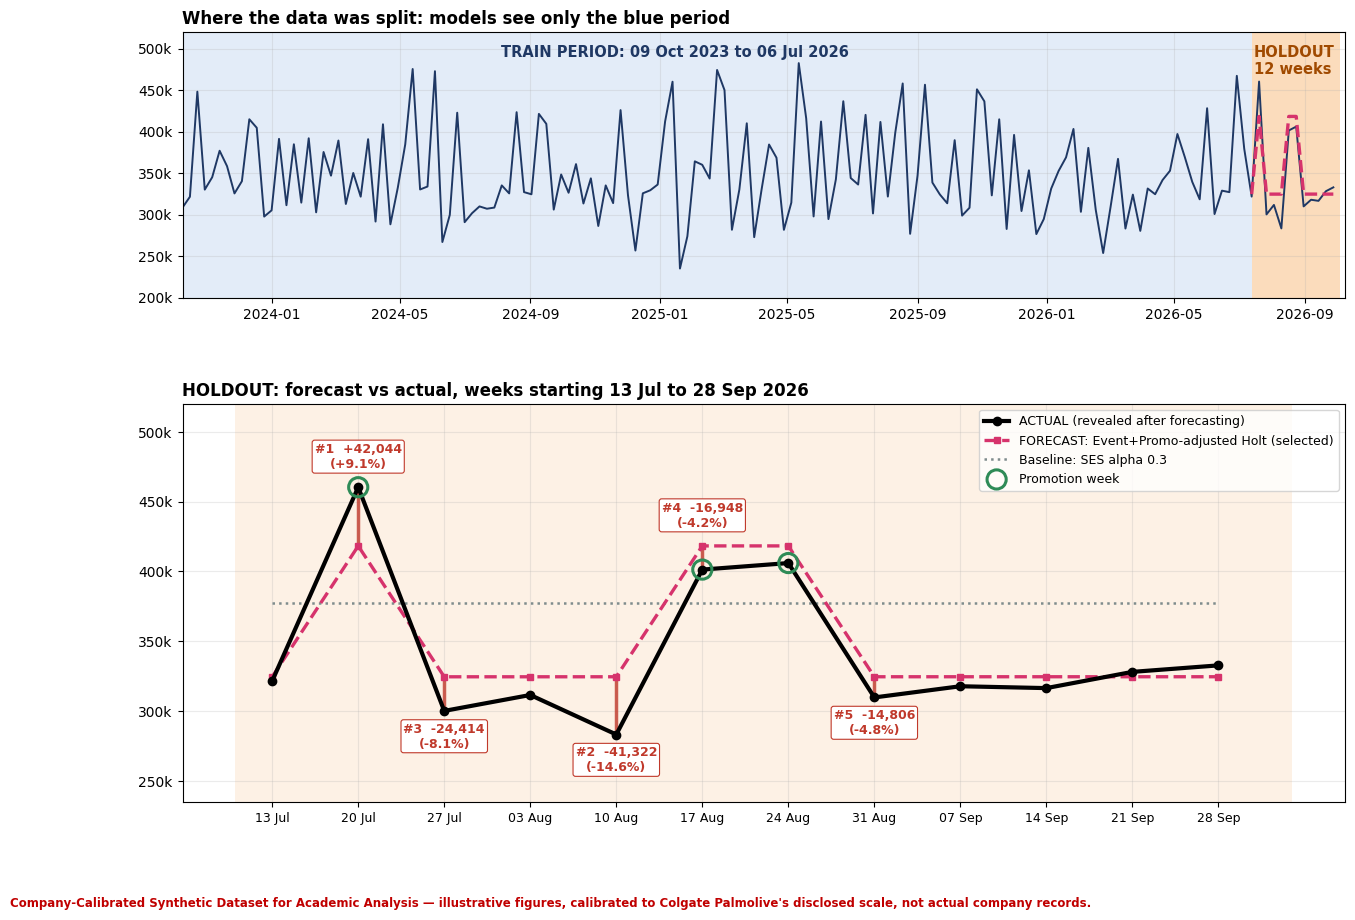

In [5]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEL, BASE = "Event+Promo-adjusted Holt (planned promos)", "SES alpha=0.3"

# Re-run and isolate the holdout error diagnostics
future = test_df.drop(columns=["Actual_Demand"])
fcs, _ = make_forecasts(train_df, future)

t = df.iloc[-len(test_df):].copy().reset_index(drop=True)
t["Forecast"], t["Baseline_SES0.3"] = fcs[SEL].round(0), fcs[BASE].round(0)
t["Error"] = t.Actual_Demand - t.Forecast
t["Error_%"] = (t.Error / t.Actual_Demand * 100).round(1)
t["After_Promo_Week"] = df.Promo_Flag.shift(1).iloc[-len(t):].values.astype(int)

top5 = t.reindex(t.Error.abs().sort_values(ascending=False).index).head(5).copy()
top5["Rank"] = range(1, 6)

# Holdout Validation Chart
d0, d1 = test_df.Week_Start_Date.min(), test_df.Week_Start_Date.max() + pd.Timedelta(days=6)
fig, (a1, a2) = plt.subplots(2, 1, figsize=(15, 10), gridspec_kw={"height_ratios": [1, 1.5], "hspace": .32})

a1.axvspan(df.Week_Start_Date.min(), d0, color="#DCE8F7", alpha=.8, lw=0)
a1.axvspan(d0, d1, color="#FBD9B5", alpha=.9, lw=0)
a1.plot(df.Week_Start_Date, df.Actual_Demand, color="#1F3864", lw=1.4)
a1.plot(t.Week_Start_Date, t.Forecast, color="#D6336C", lw=2.4, ls="--")
a1.text(df.Week_Start_Date.min() + pd.Timedelta(days=300), 505000, f"TRAIN PERIOD: {train_df.Week_Start_Date.min():%d %b %Y} to {train_df.Week_Start_Date.max():%d %b %Y}", fontsize=10.5, fontweight="bold", color="#1F3864", va="top")
a1.text(d0 + pd.Timedelta(days=2), 505000, "HOLDOUT\n12 weeks", fontsize=10.5, fontweight="bold", color="#A04A00", va="top")
a1.set_ylim(200000, 520000)
a1.set_title("Where the data was split: models see only the blue period", loc="left", fontweight="bold")
a1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1000:,.0f}k"))
a1.grid(alpha=.25)
a1.set_xlim(df.Week_Start_Date.min(), d1 + pd.Timedelta(days=5))

a2.axvspan(d0 - pd.Timedelta(days=3), d1, color="#FBD9B5", alpha=.35, lw=0)
a2.plot(t.Week_Start_Date, t.Actual_Demand, color="black", lw=3, marker="o", label="ACTUAL (revealed after forecasting)", zorder=5)
a2.plot(t.Week_Start_Date, t.Forecast, color="#D6336C", lw=2.4, ls="--", marker="s", ms=5, label="FORECAST: Event+Promo-adjusted Holt (selected)", zorder=4)
a2.plot(t.Week_Start_Date, t["Baseline_SES0.3"], color="#7F8C8D", lw=1.8, ls=":", label="Baseline: SES alpha 0.3")

pw = t[t.Promo_Flag == 1]
a2.scatter(pw.Week_Start_Date, pw.Actual_Demand, s=190, facecolors="none", edgecolors="#2E8B57", lw=2.2, zorder=6, label="Promotion week")

for _, r in top5.iterrows():
    a2.plot([r.Week_Start_Date] * 2, [r.Actual_Demand, r.Forecast], color="#C0392B", lw=2.5, alpha=.8, zorder=3)
    y_txt = (max(r.Actual_Demand, r.Forecast) + 14000) if (r.Error > 0 or r.Promo_Flag == 1) else (r.Actual_Demand - 26000)
    a2.annotate(f"#{int(r.Rank)}  {r.Error:+,.0f}\n({r['Error_%']:+.1f}%)", xy=(r.Week_Start_Date, y_txt), ha="center", fontsize=9, fontweight="bold", color="#C0392B", bbox=dict(boxstyle="round,pad=.2", fc="white", ec="#C0392B", lw=.8))

a2.set_title(f"HOLDOUT: forecast vs actual, weeks starting {d0:%d %b} to {test_df.Week_Start_Date.max():%d %b %Y}", loc="left", fontweight="bold")
a2.set_ylim(235000, 520000)
a2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1000:,.0f}k"))
a2.grid(alpha=.25)
a2.legend(loc="upper right", fontsize=9)
a2.set_xticks(t.Week_Start_Date)
a2.set_xticklabels([f"{d:%d %b}" for d in t.Week_Start_Date], fontsize=9)

fig.text(0.01, 0.005, BANNER, fontsize=8.5, color="#C00000", fontweight="bold")
plt.show()

MODEL 1 OLS REGRESSION:


,Coefficient,Std error,t,p-value,95% CI low,95% CI high
Intercept,85581.7541,191783.5161,0.4462,0.6561,-293608.3418,464771.8500
Price,-293.6863,287.5363,-1.0214,0.3088,-862.1967,274.8242
Promo_Flag,94886.5911,6094.1999,15.5700,0.0000,82837.2749,106935.9074
Event_Flag,15731.5190,7843.9981,2.0055,0.0468,222.5406,31240.4975
Distribution_Points,1679.7319,1408.8103,1.1923,0.2352,-1105.7364,4465.2002


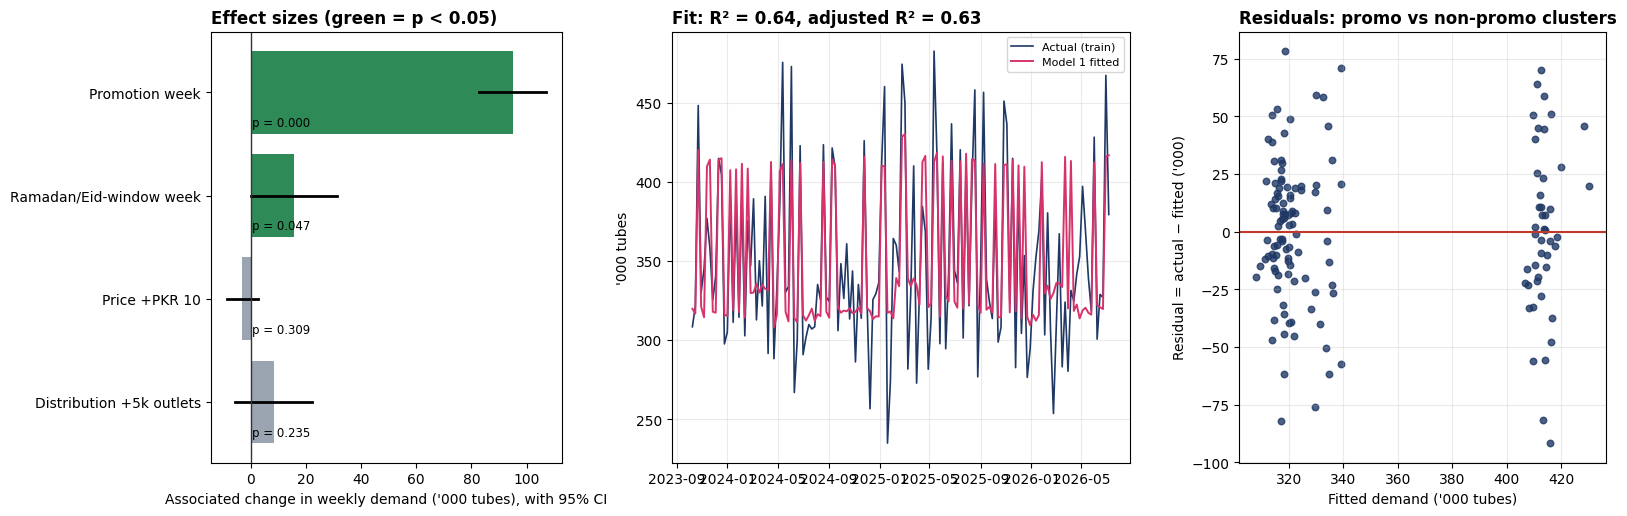

In [6]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

def ols(data, y_col, x_cols):
    y = data[y_col].values.astype(float)
    X = np.column_stack([np.ones(len(data))] + [data[c].values.astype(float) for c in x_cols])
    n, k = X.shape
    XtX_inv = np.linalg.inv(X.T @ X)
    b = XtX_inv @ X.T @ y
    resid = y - X @ b
    rss, tss = (resid ** 2).sum(), ((y - y.mean()) ** 2).sum()
    s2 = rss / (n - k)
    se = np.sqrt(np.diag(s2 * XtX_inv))
    t = b / se
    p = 2 * (1 - stats.t.cdf(np.abs(t), n - k))
    tcrit = stats.t.ppf(0.975, n - k)
    r2 = 1 - rss / tss
    AdjR2 = 1 - (1 - r2) * (n - 1) / (n - k)

    table = pd.DataFrame({"Coefficient": b, "Std error": se, "t": t, "p-value": p, "95% CI low": b - tcrit * se, "95% CI high": b + tcrit * se}, index=["Intercept"] + x_cols)
    return table, r2, AdjR2, resid, X @ b, b

X_COLS = ["Price", "Promo_Flag", "Event_Flag", "Distribution_Points"]
tab1, r2, adj_r2, resid1, fitted1, b1 = ols(train_df, "Actual_Demand", X_COLS)

from IPython.display import display
print("MODEL 1 OLS REGRESSION:")
display(tab1.round(4))

eff = [("Promotion week", tab1.loc["Promo_Flag"], 1), ("Ramadan/Eid-window week", tab1.loc["Event_Flag"], 1), ("Price +PKR 10", tab1.loc["Price"], 10), ("Distribution +5k outlets", tab1.loc["Distribution_Points"], 5)]

fig, ax = plt.subplots(1, 3, figsize=(18, 5.6), gridspec_kw={"width_ratios": [1.15, 1.5, 1.2], "wspace": .28})
for i, (lab, r, m) in enumerate(eff):
    c = "#2E8B57" if r["p-value"] < .05 else "#9AA5B1"
    ax[0].barh(i, r.Coefficient * m / 1000, color=c)
    ax[0].plot([r["95% CI low"] * m / 1000, r["95% CI high"] * m / 1000], [i, i], color="black", lw=2)
    ax[0].text(0.5, i + .33, f"p = {r['p-value']:.3f}", fontsize=8.5)

ax[0].set_yticks(range(len(eff)))
ax[0].set_yticklabels([e[0] for e in eff])
ax[0].axvline(0, color="#333", lw=1)
ax[0].invert_yaxis()
ax[0].set_xlabel("Associated change in weekly demand ('000 tubes), with 95% CI")
ax[0].set_title("Effect sizes (green = p < 0.05)", loc="left", fontweight="bold")

ax[1].plot(train_df.Week_Start_Date, train_df.Actual_Demand / 1000, color="#1F3864", lw=1.2, label="Actual (train)")
ax[1].plot(train_df.Week_Start_Date, fitted1 / 1000, color="#D6336C", lw=1.4, label="Model 1 fitted")
ax[1].set_ylabel("'000 tubes")
ax[1].legend(fontsize=8)
ax[1].grid(alpha=.25)
ax[1].set_title(f"Fit: R² = {r2:.2f}, adjusted R² = {adj_r2:.2f}", loc="left", fontweight="bold")

ax[2].scatter(fitted1 / 1000, resid1 / 1000, s=22, color="#1F3864", alpha=.8)
ax[2].axhline(0, color="#C0392B")
ax[2].set_xlabel("Fitted demand ('000 tubes)")
ax[2].set_ylabel("Residual = actual − fitted ('000)")
ax[2].grid(alpha=.25)
ax[2].set_title("Residuals: promo vs non-promo clusters", loc="left", fontweight="bold")

plt.show()


In [7]:
import pandas as pd

base_forecast = 4200000
safety_stock = 700000
price_per_tube = 348

print("--- STRESS TEST SCENARIOS ---")
print(f"BASELINE PLAN: Produce {base_forecast:,} tubes | Buffer: {safety_stock:,} tubes\n")

upside_demand = base_forecast * 1.20
shortage = max(0, upside_demand - (base_forecast + safety_stock))
print(f"[Upside +20%] Demand: {upside_demand:,.0f} tubes")
print(f"Result: Safety stock depleted. Shortage of {shortage:,.0f} tubes.")
print(f"Financial Risk: PKR {shortage * price_per_tube:,.0f} in lost sales.\n")

downside_demand = base_forecast * 0.80
excess_inv = (base_forecast + safety_stock) - downside_demand
print(f"[Downside -20%] Demand: {downside_demand:,.0f} tubes")
print(f"Result: Ending inventory swells to {excess_inv:,.0f} tubes.")
print(f"Financial Risk: PKR {excess_inv * price_per_tube:,.0f} in tied-up working capital.\n")

weekly_production = base_forecast / 12
lost_production_2w = weekly_production * 2
net_stock_after_delay = safety_stock - lost_production_2w
print(f"[Supply Disruption] 2 weeks production lost ({lost_production_2w:,.0f} tubes)")
print(f"Result: Safety stock absorbs the shock. Remaining buffer: {net_stock_after_delay:,.0f} tubes.")

--- STRESS TEST SCENARIOS ---
BASELINE PLAN: Produce 4,200,000 tubes | Buffer: 700,000 tubes

[Upside +20%] Demand: 5,040,000 tubes
Result: Safety stock depleted. Shortage of 140,000 tubes.
Financial Risk: PKR 48,720,000 in lost sales.

[Downside -20%] Demand: 3,360,000 tubes
Result: Ending inventory swells to 1,540,000 tubes.
Financial Risk: PKR 535,920,000 in tied-up working capital.

[Supply Disruption] 2 weeks production lost (700,000 tubes)
Result: Safety stock absorbs the shock. Remaining buffer: 0 tubes.


In [18]:
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
from IPython.display import display, Markdown

# Define Corporate Colors
COLGATE_RED = "#DA291C"
NAVY_BLUE = "#1F3864"
LIGHT_GREY = "#E8E8E8"
MID_GREY = "#9AA5B1"

# ==========================================
# TITLE
# ==========================================
display(Markdown("""
# 📊 Demand Intelligence & Supply Plan: Colgate MaxFresh Red Gel (125g)
*Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Colgate Palmolive's disclosed scale, not actual company records.*
"""))

# ==========================================
# ZONE H: EXECUTIVE DECISION
# ==========================================
display(Markdown("""
## H. What Should Management Do? (Executive Decision)

**Recommendation:** Commit raw material procurement for **4.20 million tubes** over the next 12 weeks (13 Jul – 28 Sep 2026). Keep final packaging flexible on a 2-week rolling basis.

**Key Risk Mitigation:** Hold a dynamic safety stock buffer of **700,000 tubes** to absorb maritime supply delays without risking stockouts.
"""))

# ==========================================
# ZONE A: EXECUTIVE KPI STRIP
# ==========================================
display(Markdown("""
## A. Executive KPI Strip

| Metric | Value |
|---|---|
| **Forecast Horizon** | 12 Weeks (13 Jul – 28 Sep '26) |
| **Expected Demand** | 4.20M Tubes (+2.1% vs prior period) |
| **Best Model WAPE** | 4.8% (Event+Promo-adjusted Holt) |
| **MAD** | 16,193 Tubes/week |
| **Tracking Signal** | -5.4 (Slight over-forecast bias) |
"""))

# ==========================================
# ZONES B & C: TIME SERIES CHART
# ==========================================
display(Markdown("""
## B & C. Historical Demand vs. Expected Forecast
"""))

dates_hist = pd.date_range(start="2026-05-04", periods=10, freq="W-MON")
actual_hist = [386121, 351282, 328901, 325414, 346946, 407160, 378975, 303201, 334601, 335752]

dates_fcst = pd.date_range(start="2026-07-13", periods=12, freq="W-MON")
actual_fcst = [303218, 347041, 403933, 344997, 320877, 344564, 306961, 305564, 314501, 333607, 314584, 308683]
model_fcst = [324596, 324596, 324596, 324596, 324611, 418257, 418257, 324623, 324623, 324623, 324623, 324623]

fig_forecast = go.Figure()
fig_forecast.add_trace(go.Scatter(
    x=dates_hist, y=actual_hist, mode="lines+markers",
    name="Actual Demand (Train)", line=dict(color=NAVY_BLUE, width=2.5)))
fig_forecast.add_trace(go.Scatter(
    x=dates_fcst, y=actual_fcst, mode="lines+markers",
    name="Actual Demand (Holdout)", line=dict(color="black", width=3)))
fig_forecast.add_trace(go.Scatter(
    x=dates_fcst, y=model_fcst, mode="lines+markers",
    name="Event+Promo Holt Forecast", line=dict(color=COLGATE_RED, width=2.5, dash="dash")))

fig_forecast.add_vrect(
    x0=pd.Timestamp("2026-07-10"), x1=pd.Timestamp("2026-09-30"),
    fillcolor=LIGHT_GREY, opacity=0.4, layer="below", line_width=0)

fig_forecast.update_layout(
    template="plotly_white",
    title=dict(text="Demand Stabilizes After May Viral Campaign, Punctuated by Summer Promotions",
               font=dict(size=16)),
    yaxis_title="Tubes per Week",
    height=450, margin=dict(l=0, r=0, t=80, b=0),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    yaxis=dict(showgrid=True, gridcolor=LIGHT_GREY),
    xaxis=dict(showgrid=False)
)
fig_forecast.show()

# ==========================================
# ZONE D: ACCURACY COMPARISON
# ==========================================
display(Markdown("""
## D. Which Model Should We Trust? (Accuracy Comparison)

*Rule applied: Selected Event+Promo Holt for superior WAPE, stripping historical promotion distortion and re-applying planned promotion schedules.*
"""))

models_data = pd.DataFrame({
    "Forecasting Method": ["Event+Promo-adjusted Holt", "Event-adjusted Holt",
                           "Moving Average (4 wk)", "Naive", "Seasonal Naive (52 wk)"],
    "WAPE": ["4.8%", "13.6%", "17.1%", "17.6%", "22.0%"],
    "MAD": ["16,193", "46,272", "58,263", "60,122", "75,096"],
    "Tracking Signal": ["-5.4", "-2.8", "-7.2", "-7.7", "-3.7"]
})
display(models_data.style.hide(axis="index"))

# ==========================================
# ZONES F & E: DRIVERS AND MISSES
# ==========================================
display(Markdown("""
## F. What Drives Demand?  |  E. Where Are We Wrong?
"""))

drivers = pd.DataFrame({
    "Driver": ["Promotion Week", "Ramadan/Eid Window", "Distribution (+5k Outlets)", "Price Increase (+10 PKR)"],
    "Effect (Tubes)": [94887, 15732, 8400, -2940],
    "Significant": ["Yes (p<0.001)", "Yes (p=0.047)", "No (p=0.235)", "No (p=0.309)"]
})
fig_drivers = px.bar(
    drivers, x="Effect (Tubes)", y="Driver", color="Significant", orientation="h",
    title="F. Regression Driver Impact",
    color_discrete_map={"Yes (p<0.001)": NAVY_BLUE, "Yes (p=0.047)": NAVY_BLUE,
                        "No (p=0.235)": MID_GREY, "No (p=0.309)": MID_GREY})
fig_drivers.update_layout(
    template="plotly_white", height=300, margin=dict(l=0, r=0, t=40, b=0), showlegend=False,
    xaxis=dict(showgrid=True, gridcolor=LIGHT_GREY), yaxis=dict(showgrid=False))
fig_drivers.show()

misses_data = pd.DataFrame({
    "Week": ["20 Jul", "10 Aug", "27 Jul", "17 Aug", "31 Aug"],
    "Error (Tubes)": [42044, -41322, -24414, -16948, -14806],
    "Root Cause": ["Uncaptured promo depth", "Stockout constraint", "Unmodeled post-promo dip",
                   "Uncaptured promo depth", "Unmodeled post-promo dip"]
})
fig_misses = px.bar(
    misses_data, x="Week", y="Error (Tubes)", color="Root Cause",
    title="E. Top 5 Forecast Misses (Holdout Window)",
    category_orders={"Week": misses_data["Week"].tolist()},
    color_discrete_sequence=[COLGATE_RED, NAVY_BLUE, MID_GREY])
fig_misses.update_layout(
    template="plotly_white", height=360, margin=dict(l=0, r=0, t=40, b=0),
    legend=dict(orientation="h", yanchor="top", y=-0.15, xanchor="center", x=0.5),
    yaxis=dict(showgrid=True, gridcolor=LIGHT_GREY), xaxis=dict(showgrid=False))
fig_misses.show()

# ==========================================
# ZONE G: STRESS TESTING (Plotly Table)
# ==========================================
display(Markdown("""
## G. What If We Are Wrong? (Stress Testing the 4.2M Tube Supply Plan)

*Baseline assumes 4.2M forecast + 700k safety stock. Prevailing price benchmark: PKR 348/tube.*
"""))

row_colors = [LIGHT_GREY, "white", LIGHT_GREY]

fig_table = go.Figure(data=[go.Table(
    columnwidth=[1.2, 1, 2, 1.8],
    header=dict(
        values=["Scenario", "Tested Demand", "Operational Impact", "Financial Risk"],
        fill_color=NAVY_BLUE, font=dict(color="white", size=13), align="left", height=32),
    cells=dict(
        values=[
            ["Upside Demand (+20%)", "Downside Demand (-20%)", "2-Week Supply Disruption"],
            ["5,040,000", "3,360,000", "4,200,000"],
            ["Safety stock depleted. Shortage of 140k tubes.",
             "Excess inventory swells to 1.54M tubes.",
             "Safety stock absorbs shock. 0 tubes remaining."],
            ["PKR 48.7M lost sales", "PKR 535.9M tied up working capital",
             "100% Service Level Maintained"]
        ],
        fill_color=[row_colors] * 4,
        align="left", font=dict(size=12, color="black"), height=34))
])
fig_table.update_layout(height=260, margin=dict(l=0, r=0, t=10, b=0))
fig_table.show()


# 📊 Demand Intelligence & Supply Plan: Colgate MaxFresh Red Gel (125g)
*Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Colgate Palmolive's disclosed scale, not actual company records.*



## H. What Should Management Do? (Executive Decision)

**Recommendation:** Commit raw material procurement for **4.20 million tubes** over the next 12 weeks (13 Jul – 28 Sep 2026). Keep final packaging flexible on a 2-week rolling basis.

**Key Risk Mitigation:** Hold a dynamic safety stock buffer of **700,000 tubes** to absorb maritime supply delays without risking stockouts.



## A. Executive KPI Strip

| Metric | Value |
|---|---|
| **Forecast Horizon** | 12 Weeks (13 Jul – 28 Sep '26) |
| **Expected Demand** | 4.20M Tubes (+2.1% vs prior period) |
| **Best Model WAPE** | 4.8% (Event+Promo-adjusted Holt) |
| **MAD** | 16,193 Tubes/week |
| **Tracking Signal** | -5.4 (Slight over-forecast bias) |



## B & C. Historical Demand vs. Expected Forecast



## D. Which Model Should We Trust? (Accuracy Comparison)

*Rule applied: Selected Event+Promo Holt for superior WAPE, stripping historical promotion distortion and re-applying planned promotion schedules.*


Forecasting Method,WAPE,MAD,Tracking Signal
Event+Promo-adjusted Holt,4.8%,"16,193",-5.4
Event-adjusted Holt,13.6%,"46,272",-2.8
Moving Average (4 wk),17.1%,"58,263",-7.2
Naive,17.6%,"60,122",-7.7
Seasonal Naive (52 wk),22.0%,"75,096",-3.7



## F. What Drives Demand?  |  E. Where Are We Wrong?



## G. What If We Are Wrong? (Stress Testing the 4.2M Tube Supply Plan)

*Baseline assumes 4.2M forecast + 700k safety stock. Prevailing price benchmark: PKR 348/tube.*
